ابعاد دیتاست: (566, 38)

۵ ردیف اول:
     PATIENT_ID SUBTYPE CANCER_TYPE_ACRONYM  \
0  TCGA-05-4244    LUAD                LUAD   
1  TCGA-05-4249    LUAD                LUAD   
2  TCGA-05-4250    LUAD                LUAD   
3  TCGA-05-4382    LUAD                LUAD   
4  TCGA-05-4384    LUAD                LUAD   

                       OTHER_PATIENT_ID   AGE     SEX  \
0  34040b83-7e8a-4264-a551-b16621843e28  70.0    Male   
1  4addf05f-3668-4b3f-a17f-c0227329ca52  67.0    Male   
2  f98ecd8a-b878-4f53-b911-20cd8e17281c  79.0  Female   
3  3434b91a-c05f-460f-a078-7b1bb6e7085d  68.0    Male   
4  9a50e7e4-831d-489f-87d2-979e987561cc  66.0    Male   

  AJCC_PATHOLOGIC_TUMOR_STAGE AJCC_STAGING_EDITION  DAYS_LAST_FOLLOWUP  \
0                    STAGE IV                  6TH                 0.0   
1                    STAGE IB                  6TH              1523.0   
2                  STAGE IIIA                  6TH                 NaN   
3                    STAGE IB            

C:\Users\pc\AppData\Local\Temp\ipykernel_6148\3882743774.py:66: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_raw.select_dtypes(include=['object']).columns.tolist()



آموزش مدل: Logistic Regression
Accuracy : 0.7287
ROC-AUC  : 0.7639

گزارش طبقه‌بندی:
              precision    recall  f1-score   support

           0       0.76      0.84      0.80        82
           1       0.66      0.53      0.59        47

    accuracy                           0.73       129
   macro avg       0.71      0.69      0.69       129
weighted avg       0.72      0.73      0.72       129


آموزش مدل: Random Forest
Accuracy : 0.7597
ROC-AUC  : 0.8055

گزارش طبقه‌بندی:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82        82
           1       0.69      0.62      0.65        47

    accuracy                           0.76       129
   macro avg       0.74      0.73      0.73       129
weighted avg       0.76      0.76      0.76       129


آموزش مدل: Gradient Boosting
Accuracy : 0.6977
ROC-AUC  : 0.7724

گزارش طبقه‌بندی:
              precision    recall  f1-score   support

           0       0.76      0.77      0.

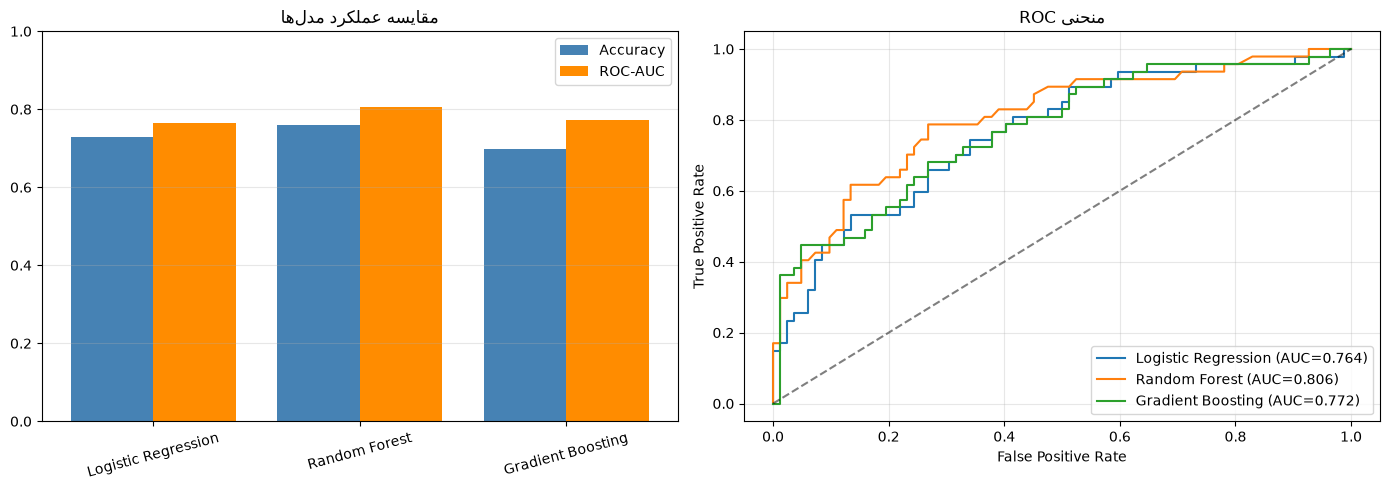

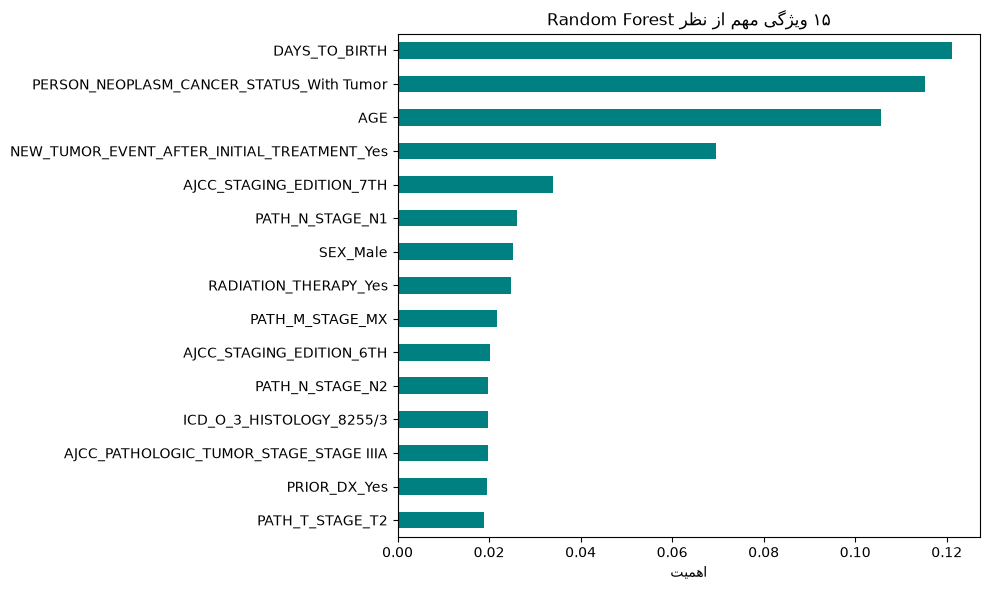


۱۵ ویژگی مهم:
DAYS_TO_BIRTH                                  0.121205
PERSON_NEOPLASM_CANCER_STATUS_With Tumor       0.115174
AGE                                            0.105715
NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT_Yes    0.069624
AJCC_STAGING_EDITION_7TH                       0.034073
PATH_N_STAGE_N1                                0.026207
SEX_Male                                       0.025237
RADIATION_THERAPY_Yes                          0.024843
PATH_M_STAGE_MX                                0.021701
AJCC_STAGING_EDITION_6TH                       0.020183
PATH_N_STAGE_N2                                0.019757
ICD_O_3_HISTOLOGY_8255/3                       0.019717
AJCC_PATHOLOGIC_TUMOR_STAGE_STAGE IIIA         0.019665
PRIOR_DX_Yes                                   0.019607
PATH_T_STAGE_T2                                0.018848
dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

# ============================================================
# ۱. بارگذاری داده‌ها
# ============================================================
filename = "./datasets/data_clinical_patient.txt"

# ۴ خط اول متادیتا هستند، از خط ۵ (ایندکس ۴) هدر اصلی شروع می‌شود
df = pd.read_csv(filename, sep='\t', skiprows=4, low_memory=False)

print("=" * 60)
print("ابعاد دیتاست:", df.shape)
print("=" * 60)
print("\n۵ ردیف اول:")
print(df.head())
print("\nنام ستون‌ها:")
print(df.columns.tolist())

# ============================================================
# ۲. انتخاب ویژگی‌ها و هدف
# ============================================================
# هدف: وضعیت بقای کلی (OS_STATUS)
target_col = 'OS_STATUS'

# حذف ستون‌هایی که نشت داده (data leakage) ایجاد می‌کنند
leakage_cols = [
    'PATIENT_ID', 'OTHER_PATIENT_ID', 'OS_STATUS', 'OS_MONTHS',
    'DSS_STATUS', 'DSS_MONTHS', 'DFS_STATUS', 'DFS_MONTHS',
    'PFS_STATUS', 'PFS_MONTHS', 'DAYS_LAST_FOLLOWUP',
    'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS',
    'FORM_COMPLETION_DATE', 'IN_PANCANPATHWAYS_FREEZE'
]

feature_df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

# حذف ردیف‌هایی که هدف آن‌ها خالی است
mask = df[target_col].notna()
X_raw = feature_df[mask].copy()
y_raw = df.loc[mask, target_col].copy()

print("\nتوزیع کلاس هدف:")
print(y_raw.value_counts())

# ============================================================
# ۳. پیش‌پردازش
# ============================================================
# --- حذف ستون‌های با مقادیر گمشده بیش از ۵۰٪ ---
missing_ratio = X_raw.isnull().mean()
cols_to_keep = missing_ratio[missing_ratio < 0.5].index
X_raw = X_raw[cols_to_keep]
print(f"\nتعداد ویژگی‌ها پس از حذف ستون‌های خیلی خالی: {X_raw.shape[1]}")

# --- جدا کردن ویژگی‌های عددی و دسته‌ای ---
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_raw.select_dtypes(include=['object']).columns.tolist()

# --- پر کردن مقادیر گمشده ---
if num_cols:
    num_imputer = SimpleImputer(strategy='median')
    X_num = pd.DataFrame(num_imputer.fit_transform(X_raw[num_cols]),
                         columns=num_cols, index=X_raw.index)
else:
    X_num = pd.DataFrame(index=X_raw.index)

if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_cat = pd.DataFrame(cat_imputer.fit_transform(X_raw[cat_cols]),
                         columns=cat_cols, index=X_raw.index)
    # --- کدگذاری One-Hot ---
    X_cat = pd.get_dummies(X_cat, drop_first=True)
else:
    X_cat = pd.DataFrame(index=X_raw.index)

# --- ترکیب ---
X = pd.concat([X_num, X_cat], axis=1)
X = X.astype(float)

# --- کدگذاری هدف: 0:LIVING -> 0 ، 1:DECEASED -> 1 ---
y = y_raw.apply(lambda v: 1 if 'DECEASED' in str(v) else 0)

print("\nتوزیع نهایی کلاس هدف:")
print(y.value_counts())
print(f"\nابعاد نهایی X: {X.shape}")

# ============================================================
# ۴. تقسیم داده به آموزش و آزمون
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# --- استانداردسازی ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# ۵. آموزش مدل‌ها
# ============================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results = {}
for name, model in models.items():
    print("\n" + "=" * 60)
    print(f"آموزش مدل: {name}")
    print("=" * 60)

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_prob)
    except ValueError:
        auc = float('nan')

    results[name] = {"accuracy": acc, "auc": auc, "model": model, "prob": y_prob}

    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("\nگزارش طبقه‌بندی:")
    print(classification_report(y_test, y_pred, zero_division=0))

# ============================================================
# ۶. مصورسازی نتایج
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- نمودار مقایسه Accuracy و AUC ---
names = list(results.keys())
accs = [results[n]['accuracy'] for n in names]
aucs = [results[n]['auc'] for n in names]

x = np.arange(len(names))
axes[0].bar(x - 0.2, accs, 0.4, label='Accuracy', color='steelblue')
axes[0].bar(x + 0.2, aucs, 0.4, label='ROC-AUC', color='darkorange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=15)
axes[0].set_ylim(0, 1)
axes[0].set_title('مقایسه عملکرد مدل‌ها')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# --- منحنی ROC ---
for name in names:
    fpr, tpr, _ = roc_curve(y_test, results[name]['prob'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={results[name]['auc']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('منحنی ROC')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('tcga_ml_results.png', dpi=150)
plt.show()

# ============================================================
# ۷. اهمیت ویژگی‌ها (برای Random Forest)
# ============================================================
rf = results["Random Forest"]["model"]
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('۱۵ ویژگی مهم از نظر Random Forest')
plt.xlabel('اهمیت')
plt.tight_layout()
plt.savefig('tcga_feature_importance.png', dpi=150)
plt.show()

print("\n۱۵ ویژگی مهم:")
print(top_features)